In [14]:
import numpy as np
path0 = './'
filename = 'all_candidate_paraphrase_pairs.txt'
threshold = 0.65  # adjust this value as needed

data = []
with open(f"{path0}{filename}", "r") as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) == 9:
            (sentence1, sentence2, original, paraphrase, 
             tags1, tags2, len1, len2, word_overlap) = parts
            try:
                if float(word_overlap) < threshold and int(len1) > 5 and int(len2) > 5:
                    data.append((sentence1, sentence2, original, paraphrase, len1, len2, tags1, tags2))
            except ValueError:
                continue  # skip lines with non-numeric word_overlap

print(f'{len(data)=}')

for i in range(2):
    print(data[i])

len(data)=2018
('After falling to the ground, the child cried', 'The child fell on the ground and cried', 'The child fell on the ground and cried', 'After falling to the ground, the child cried', '8', '9', 'DT NN VBD IN DT NN CC VBD', 'IN VBG IN DT NN , DT NN VBD')
('That master tune rings with eternal beauty', 'The music composed by a master sounds timeless', 'The music composed by a master sounds timeless', 'That master tune rings with eternal beauty', '8', '7', 'DT NN VBN IN DT NN VBZ JJ', 'DT NN NN VBZ IN JJ NN')


In [15]:
### ORIGINALS TO SENTENCES0.TXT !! 
with open("sentences0.txt", "w") as f1, \
  open("sentences1.txt", "w") as f2:
    for idx in range(len(data)):
      original,paraphrase = data[idx][2],data[idx][3]
      f1.write(original + "\n")
      f2.write(paraphrase + "\n")

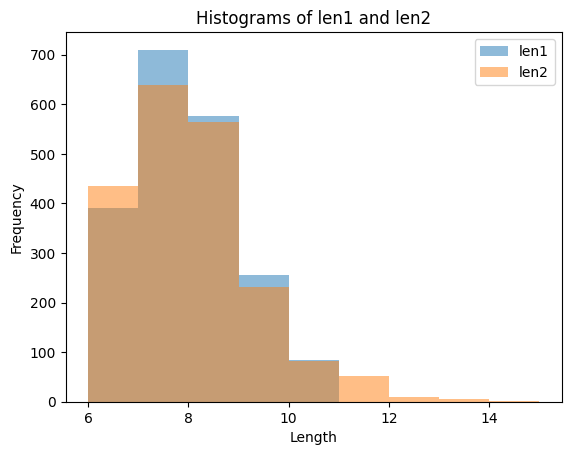

In [16]:
### distribution of lengths

import matplotlib.pyplot as plt

# Extract len1 and len2 as integers
len1_list = [int(item[4]) for item in data]
len2_list = [int(item[5]) for item in data]

plt.hist(len1_list, bins=range(min(len1_list), max(len1_list)+2), alpha=0.5, label='len1')
plt.hist(len2_list, bins=range(min(len2_list), max(len2_list)+2), alpha=0.5, label='len2')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histograms of len1 and len2')
plt.show()

### Removing syntax experiment

In [17]:
def get_group_ids(data, 
                  file1_path, 
                  file2_path, 
                  group_ids_path, 
                  ):
  # Read all lines from the first file into a list and dict for fast lookup
  with open(file1_path, "r") as f1:
    lines1 = [line.strip() for line in f1]
    line_to_idx1 = {line: idx for idx, line in enumerate(lines1)}
  # Read all lines from the second file into a list and dict for fast lookup
  with open(file2_path, "r") as f2:
    lines2 = [line.strip() for line in f2]
    line_to_idx2 = {line: idx for idx, line in enumerate(lines2)}
  # Read group ids
  with open(group_ids_path, "r") as fgid:
    original_group_ids = [line.strip() for line in fgid]

  results = []

  for data_idx, (sentence1, sentence2, original, *_) in enumerate(data):

    ### First we check if the original sentence is in either file
    if original in line_to_idx1:
      original_in_1 = True
    else:
      original_in_1 = False 

    if original in line_to_idx2:
      original_in_2 = True
    else:
      original_in_2 = False

    if original == sentence1:
      label = 0
    elif original == sentence2:
      label = 1
    else:
      print('ERROR') ; break

    if original_in_1:
      idx1 = line_to_idx1[original]
      group_id1 = original_group_ids[idx1] 
      results.append((data_idx, label, int(group_id1)))
    elif original_in_2:
      idx2 = line_to_idx2[original]
      group_id2 = original_group_ids[idx2]
      results.append((data_idx, label, int(group_id2)))
    # else:
    #     print(f"[MISSING] '{original}' {data_idx=})")

  return results

file1 = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences0.txt"
file2 = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/sentences1.txt"
group_ids_path = "/home/acevedo/syn-sem/datasets/txt/syn/second/matching/english/group_ids.txt"

""" Given the dataset of paraphrases, I use the label of who’s the 
"original" sentence (as opposed to its corresponding paraphrase). 
For that one, I have its "syntax group id", and then I can subtract to it
its corresponding "average syntax group center" vector, 
that I computed in the previous experiment. Note that this modification is only performed
in "feature space A".
"""
results = get_group_ids(
                        data, file1, file2, group_ids_path,
                      )

print(f'{len(results)=}')
for i in range(5):
  print(results[i])

len(results)=1612
(0, 1, 31)
(1, 1, 37)
(2, 0, 65)
(3, 0, 9)
(4, 1, 94)


In [18]:
output_path_group_ids = "all_group_ids_A.txt"

L = 1600
counter = 0
selected_indices = []

with open(output_path_group_ids, "w") as f_groups:
  with open('sem_ids.txt','w') as f_sem:
    for data_idx, label, group_id in results:
      if counter < L:
        f_groups.write(f"{group_id}\n")
        f_sem.write(f'{data_idx}\n')
        counter += 1
        selected_indices.append(data_idx)

print(f'{len(selected_indices)=}')

len(selected_indices)=1600


In [19]:
filtered_data = [data[idx] for idx in selected_indices]
print(f"Filtered data size: {len(filtered_data)}")

Filtered data size: 1600


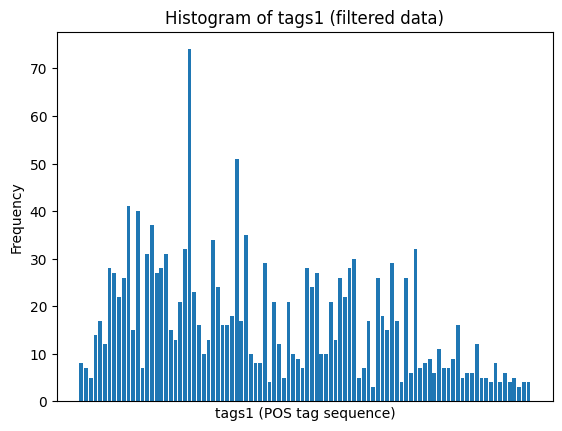

In [20]:
from collections import Counter

# Collect tags1 from filtered data (selected_indices)
tags1_filtered = [filtered_data[idx][-2] for idx in range(len(filtered_data))]

# Count occurrences of each unique tags1 string
tags1_counts = Counter(tags1_filtered)

plt.bar(tags1_counts.keys(), tags1_counts.values())
plt.xticks([], [])
plt.xlabel('tags1 (POS tag sequence)')
plt.ylabel('Frequency')
plt.title('Histogram of tags1 (filtered data)')
plt.show()

len(data)=2018


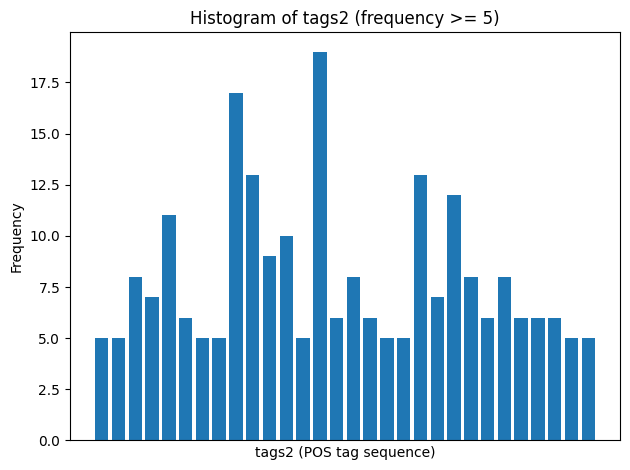

In [21]:
print(f'{len(data)=}')
threshold_counts = 5

# Collect tags1 from data (not from filtered_data)
tags2_filtered = [data[idx][-1] for idx in range(len(data))]

# Count occurrences of each unique tags1 string
tags2_counts = Counter(tags2_filtered)

# Filter tags2_counts to only include tags2 with frequency > 5
tags2_common = {tag: count for tag, count in tags2_counts.items() if count >= threshold_counts}
tags2_rare = {tag: count for tag, count in tags2_counts.items() if count < threshold_counts}

plt.bar(tags2_common.keys(), tags2_common.values())
plt.xticks([], [])
plt.xlabel('tags2 (POS tag sequence)')
plt.ylabel('Frequency')
plt.title(f'Histogram of tags2 (frequency >= {threshold_counts})')
plt.tight_layout()
plt.show()

In [22]:
total_tags2_common = sum(tags2_common.values())
print(f"Total count of tags2_common: {total_tags2_common}")

total_tags2_rare = sum(tags2_rare.values())
print(f"Total count of tags2_rare: {total_tags2_rare}")

total_tags2_rare + total_tags2_common

Total count of tags2_common: 237
Total count of tags2_rare: 1781


2018

In [23]:
# Filter (again) the filtered_data by removing entries with tags2 in tags2_rare
filtered_indices = [
  idx for idx in range(len(filtered_data))
  if filtered_data[idx][-1] not in tags2_rare and filtered_data[idx][-1] in tags2_common
]
filtered_data_final = [filtered_data[idx] for idx in filtered_indices]
print(f"{len(filtered_data_final)=}")

len(filtered_data_final)=206


In [24]:
# Indices that select the sentences for which I can subtract syntax ceners in both A and B. 
# They select sentences from the filtered_data, i.e., filtered to be in the syntax-similarity experiment.
with open("syn_syn_indices.txt", "w") as f1:
  for idx in filtered_indices:
    f1.write(f"{idx}\n")

In [37]:
tag2_to_group_id = {tag: idx for idx, tag in enumerate(tags2_common.keys())}
print(f'There are {len(tag2_to_group_id)} unique syntax structures in paraphrases')

There are 30 unique syntax structures in paraphrases


### To give a group_id to each sentence in syn_syn_indices.txt

In [47]:
all_group_ids_B = [ tag2_to_group_id[element[-1]] for idx, element in enumerate(filtered_data) if idx in filtered_indices]
with open("all_group_ids_B.txt",'w') as f:
   for group_id_B in all_group_ids_B:
      f.write(f'{group_id_B}\n')
print(f'{len(all_group_ids_B)=}')


len(all_group_ids_B)=206


### To compute syntax_centers_B: common indices_B and group_ids_B

In [ ]:
indices_tags2_common = [
  idx for idx, item in enumerate(data)
  if item[-1] in tags2_common
]
print(f"{len(indices_tags2_common)=}")

# Assign a unique group_id to each unique tag in tags2_common
all_group_ids_B = [ tag2_to_group_id[element[-1]] for idx, element in enumerate(data) if idx in indices_tags2_common ]
print(f'{len(all_group_ids_B)=}')


len(indices_tags2_common)=237
There are 30 unique syntax structures in paraphrases
len(all_group_ids_B)=237


In [45]:
with open("syn_common_indices_B.txt",'w') as f:
    for idx in indices_tags2_common:
      f.write(f'{idx}\n')
with open("common_group_ids_B.txt",'w') as f:
   for group_id_B in all_group_ids_B:
      f.write(f'{group_id_B}\n')
    